# 🏋️ Ejercicio Práctico: Regresión Lineal - Predicción de Salarios
## Curso: Machine Learning con Python (IFCD093PO)

---

## 📋 Descripción del Problema

Una empresa quiere predecir el salario de sus empleados basándose en **años de experiencia**.

Tienes un dataset histórico con:
- **X**: Años de experiencia de cada empleado
- **y**: Salario anual en miles de euros (€1000)

### 🎯 Tu Misión:
1. Cargar y explorar los datos
2. Dividir en conjunto de entrenamiento y prueba
3. Entrenar un modelo de Regresión Lineal
4. Evaluar el modelo
5. Hacer predicciones para nuevos empleados

---

## 📊 Dataset

Aquí está el conjunto de datos que usaremos:

| Años de Experiencia | Salario (€1000) |
|---------------------|----------------|
| 1.5 | 40.5 |
| 3.2 | 60.8 |
| 4.8 | 82.3 |
| 5.5 | 88.9 |
| 7.2 | 110.5 |
| 8.1 | 125.3 |
| 9.5 | 138.2 |
| 10.3 | 155.7 |
| 12.1 | 175.3 |
| 14.8 | 198.5 |

---

## ✍️ EJERCICIO: Completa el Código

### 📝 Instrucciones:

Sigue estos pasos para completar el ejercicio. **Lee los comentarios cuidadosamente** - contienen pistas sobre qué debes hacer.

### PASO 1️⃣: Importar Librerías

✅ **Pista 1**: Necesitas importar:
- `numpy` para operaciones numéricas
- `pandas` para trabajar con datos
- `matplotlib.pyplot` para visualizar
- `train_test_split` de `sklearn.model_selection` para dividir datos
- `LinearRegression` de `sklearn.linear_model` para crear el modelo
- `metrics` de `sklearn` para evaluar el modelo

In [5]:
# TODO: Importa las librerías necesarias aquí
# Necesitas: numpy, pandas, matplotlib.pyplot, train_test_split, LinearRegression, metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
# ... completa las importaciones de sklearn ...
from sklearn.model_selection import train_test_split

### PASO 2️⃣: Crear el Dataset

✅ **Pista 2**: Crea un DataFrame con dos columnas:
- Columna 'experiencia': años de experiencia
- Columna 'salario': salario en miles de euros

Puedes usar `pd.DataFrame()` y pasarle un diccionario con los datos.

In [6]:
# TODO: Crea el dataset usando un diccionario y pd.DataFrame()
# Usa las columnas 'experiencia' y 'salario'

datos = {
    'experiencia': [1.5, 3.2, 4.8, 5.5, 7.2, 8.1, 9.5, 10.3, 12.1, 14.8],
    'salario': [40.5, 60.8, 82.3, 88.9, 110.5, 125.3, 138.2, 155.7, 175.3, 198.5]
}

# Crea el DataFrame aquí
# df_salarios = ...
df_salarios = pd.DataFrame(datos)
# Muestra las primeras filas para verificar
display(df_salarios.head())
# display(df_salarios.head())

,experiencia,salario
0,1.5,40.5
1,3.2,60.8
2,4.8,82.3
3,5.5,88.9
4,7.2,110.5


### PASO 3️⃣: Visualizar los Datos

✅ **Pista 3**: Crea un gráfico de dispersión para ver la relación entre experiencia y salario.
- Eje X: experiencia
- Eje Y: salario
- Usa `plt.scatter()` para los puntos
- Añade etiquetas con `plt.xlabel()` y `plt.ylabel()`
- Título con `plt.title()`

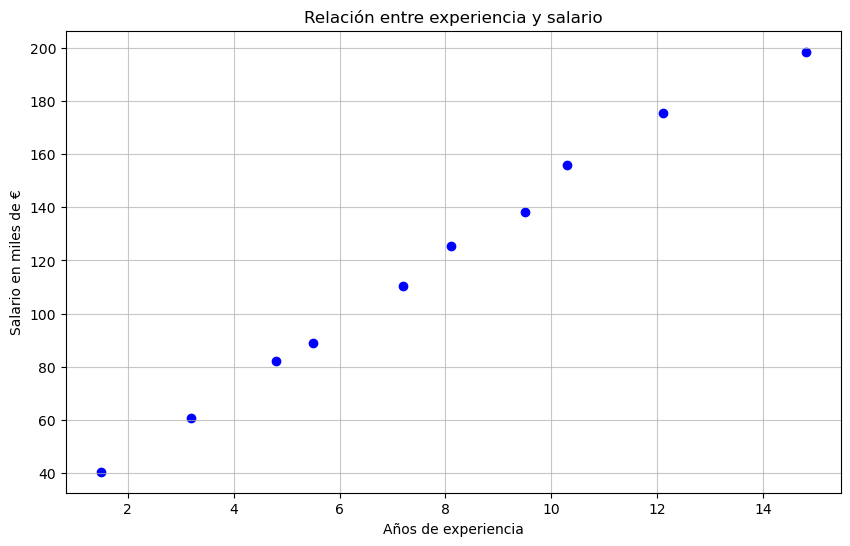

¿Puedes ver una tendencia lineal? ¿El salario sube cuando sube la experiencia?


In [17]:
# TODO: Crea un gráfico de dispersión
# Usa plt.scatter() con los datos
# Añade xlabel, ylabel y title

plt.figure(figsize=(10, 6))
# plt.scatter(...)
plt.scatter(df_salarios['experiencia'], df_salarios['salario'], color='blue', marker='o')

# plt.xlabel(...)
plt.xlabel('Años de experiencia')
# plt.ylabel(...)
plt.ylabel('Salario en miles de €')
# plt.title(...)
plt.title('Relación entre experiencia y salario')
# plt.grid(True, alpha=0.3)
plt.grid(True, alpha=0.7)
# plt.show()
plt.show()

print("¿Puedes ver una tendencia lineal? ¿El salario sube cuando sube la experiencia?")

### PASO 4️⃣: Preparar Datos (Separar X e y)

✅ **Pista 4**: Separa las características (X) de la variable objetivo (y):
- **X**: DataFrame con la columna 'experiencia' (usa `df[['experiencia']]`)
- **y**: Serie con la columna 'salario' (usa `df['salario']`)

⚠️ **Importante**: X debe ser un DataFrame (con dobles corchetes `[[]]`), no una Serie.

In [8]:
# TODO: Separa X (características) e y (objetivo)
# X = df_salarios[['experiencia']]  # Usa dobles corchetes
# y = df_salarios['salario']        # Usa un solo corchete
X = df_salarios[['experiencia']]  # Usa dobles corchetes
y = df_salarios['salario']        # Usa un solo corchete
# X = ...
# y = ...

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"\nPrimeras filas de X:\n{X.head()}")
print(f"\nPrimeros valores de y:\n{y.head()}")

Forma de X: (10, 1)
Forma de y: (10,)

Primeras filas de X:
   experiencia
0          1.5
1          3.2
2          4.8
3          5.5
4          7.2

Primeros valores de y:
0     40.5
1     60.8
2     82.3
3     88.9
4    110.5
Name: salario, dtype: float64


### PASO 5️⃣: Dividir en Entrenamiento y Prueba

✅ **Pista 5**: Usa `train_test_split()` para dividir los datos:
- Parámetros: `X`, `y`, `test_size=0.3`, `random_state=42`
- Te devolverá 4 variables: `X_train`, `X_test`, `y_train`, `y_test`

In [9]:
# TODO: Divide los datos usando train_test_split
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = ...

print(f"Tamaño conjunto entrenamiento: {len(X_train)} ejemplos")
print(f"Tamaño conjunto prueba: {len(X_test)} ejemplos")

Tamaño conjunto entrenamiento: 8 ejemplos
Tamaño conjunto prueba: 2 ejemplos


### PASO 6️⃣: Crear y Entrenar el Modelo

✅ **Pista 6**: Crea un modelo de Regresión Lineal y entrénalo:
1. Crea una instancia: `modelo = LinearRegression()`
2. Entrena con: `modelo.fit(X_train, y_train)`

In [10]:
# TODO: Crea y entrena el modelo
# modelo = LinearRegression()
# modelo.fit(X_train, y_train)
modelo = LinearRegression()
modelo.fit(X_train, y_train)
# modelo = ...
# modelo.fit(...)

print("✅ Modelo entrenado correctamente")
print(f"\nCoeficiente (pendiente): {modelo.coef_[0]:.4f}")
print(f"Intercepto: {modelo.intercept_:.4f}")
print(f"\nEcuación: Salario = {modelo.intercept_:.2f} + {modelo.coef_[0]:.2f} × Experiencia")

✅ Modelo entrenado correctamente

Coeficiente (pendiente): 12.0942
Intercepto: 24.2111

Ecuación: Salario = 24.21 + 12.09 × Experiencia


### PASO 7️⃣: Hacer Predicciones

✅ **Pista 7**: Usa el modelo entrenado para hacer predicciones:
- `y_pred_train = modelo.predict(X_train)` en el conjunto de entrenamiento
- `y_pred_test = modelo.predict(X_test)` en el conjunto de prueba

In [11]:
# TODO: Haz predicciones con el modelo
# y_pred_train = modelo.predict(X_train)
# y_pred_test = modelo.predict(X_test)
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)
# y_pred_train = ...
# y_pred_test = ...

print(f"Predicciones en entrenamiento (primeras 5): {y_pred_train[:5]}")
print(f"Valores reales en entrenamiento (primeras 5): {y_train.values[:5]}")

Predicciones en entrenamiento (primeras 5): [122.17399536  42.35239704 148.7811948   82.2631962  203.20501183]
Valores reales en entrenamiento (primeras 5): [125.3  40.5 155.7  82.3 198.5]


### PASO 8️⃣: Evaluar el Modelo

✅ **Pista 8**: Calcula métricas de evaluación:
- **MAE** (Error Absoluto Medio): `metrics.mean_absolute_error(y_test, y_pred_test)`
- **MSE** (Error Cuadrático Medio): `metrics.mean_squared_error(y_test, y_pred_test)`
- **RMSE**: La raíz cuadrada del MSE
- **R²** (Coeficiente de Determinación): `modelo.score(X_test, y_test)`

In [12]:
# TODO: Calcula las métricas de evaluación
# mae = metrics.mean_absolute_error(y_test, y_pred_test)
# mse = metrics.mean_squared_error(y_test, y_pred_test)
# rmse = np.sqrt(mse)
# r2 = modelo.score(X_test, y_test)
mae = metrics.mean_absolute_error(y_test, y_pred_test)
mse = metrics.mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = modelo.score(X_test, y_test)
# mae = ...
# mse = ...
# rmse = ...
# r2 = ...

print("📊 MÉTRICAS DE EVALUACIÓN:")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"MAE (Error Absoluto Medio): {mae:.4f} (en miles de €)")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.4f} (en miles de €)")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"\n✅ Interpretación:")
print(f"   - MAE: En promedio, el modelo se equivoca en ±{mae:.2f}K€")
print(f"   - R²: El modelo explica el {r2*100:.1f}% de la variabilidad de los salarios")

📊 MÉTRICAS DE EVALUACIÓN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAE (Error Absoluto Medio): 3.4309 (en miles de €)
MSE (Error Cuadrático Medio): 13.5092
RMSE (Raíz del Error Cuadrático): 3.6755 (en miles de €)
R² (Coeficiente de Determinación): 0.9959
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Interpretación:
   - MAE: En promedio, el modelo se equivoca en ±3.43K€
   - R²: El modelo explica el 99.6% de la variabilidad de los salarios


### PASO 9️⃣: Visualizar Resultados

✅ **Pista 9**: Crea un gráfico que muestre:
- Los puntos reales (scatter plot)
- La línea de regresión (plot)

**Sugerencia de código**:
```python
plt.scatter(X_test, y_test, color='blue', label='Valores Reales')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Predicción del Modelo')
```

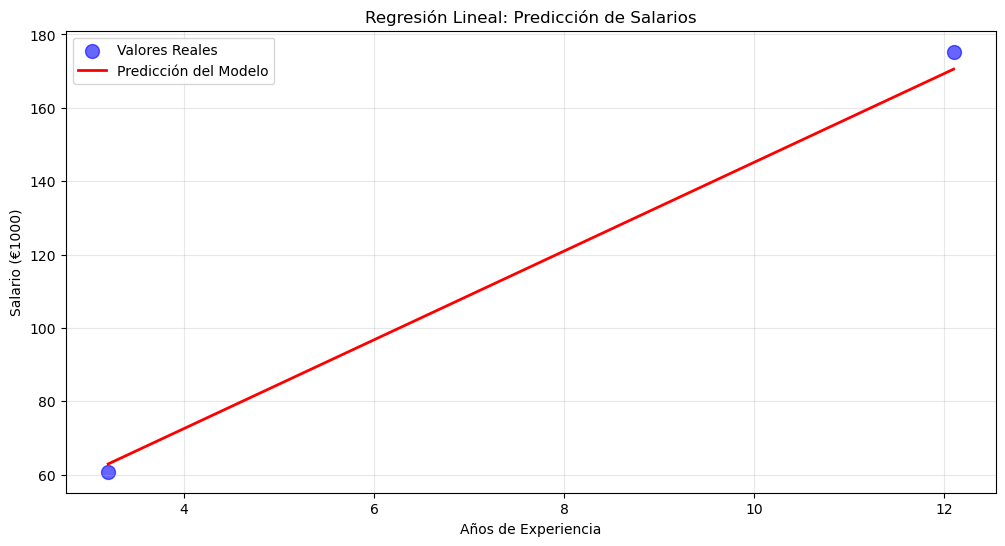

In [13]:
# TODO: Crea un gráfico mostrando los datos reales vs predichos
# Usa scatter para los datos reales y plot para la línea de regresión

plt.figure(figsize=(12, 6))

# Grafica los datos reales del conjunto de prueba
# plt.scatter(X_test, y_test, color='blue', s=100, label='Valores Reales', alpha=0.6)
plt.scatter(X_test, y_test, color='blue', s=100, label='Valores Reales', alpha=0.6)
# Grafica la línea de regresión
# plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Predicción del Modelo')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Predicción del Modelo')
# plt.xlabel('Años de Experiencia')
plt.xlabel('Años de Experiencia')
# plt.ylabel('Salario (€1000)')
plt.ylabel('Salario (€1000)')
# plt.title('Regresión Lineal: Predicción de Salarios')
plt.title('Regresión Lineal: Predicción de Salarios')
# plt.legend()
plt.legend()
# plt.grid(True, alpha=0.3)
plt.grid(True, alpha=0.3)
# plt.show()
plt.show()

### PASO 🔟: Predicciones para Nuevos Empleados

✅ **Pista 10**: Usa el modelo para predecir salarios de empleados nuevos:

```python
nuevo_empleado = [[5.0]]  # 5 años de experiencia
salario_predicho = modelo.predict(nuevo_empleado)
```

❗ **Importante**: El argumento de `predict()` debe ser un array 2D (lista de listas).

In [16]:
# TODO: Haz predicciones para nuevos empleados
import warnings 
warnings.filterwarnings("ignore")
print("🔮 PREDICCIONES PARA NUEVOS EMPLEADOS:")
print("="*50)

# Predice para un empleado con 5 años de experiencia
# nuevo_empleado_1 = [[5.0]]
# salario_1 = modelo.predict(nuevo_empleado_1)[0]
nuevo_empleado_1 = [[5.0]]
salario_1 = modelo.predict(nuevo_empleado_1)[0]
# Predice para un empleado con 6.5 años de experiencia
# nuevo_empleado_2 = [[6.5]]
# salario_2 = modelo.predict(nuevo_empleado_2)[0]
nuevo_empleado_2 = [[6.5]]
salario_2 = modelo.predict(nuevo_empleado_2)[0]
# Predice para un empleado con 15 años de experiencia
# nuevo_empleado_3 = [[15.0]]
# salario_3 = modelo.predict(nuevo_empleado_3)[0]
nuevo_empleado_3 = [[15.0]]
salario_3 = modelo.predict(nuevo_empleado_3)[0]
# print(f"Empleado con 5.0 años de experiencia: {salario_1:.2f}K€")
print(f"Empleado con 5.0 años de experiencia: {salario_1:.2f}K€")
# print(f"Empleado con 6.5 años de experiencia: {salario_2:.2f}K€")
print(f"Empleado con 6.5 años de experiencia: {salario_2:.2f}K€")
# print(f"Empleado con 15.0 años de experiencia: {salario_3:.2f}K€")
print(f"Empleado con 15.0 años de experiencia: {salario_3:.2f}K€")

🔮 PREDICCIONES PARA NUEVOS EMPLEADOS:
Empleado con 5.0 años de experiencia: 84.68K€
Empleado con 6.5 años de experiencia: 102.82K€
Empleado con 15.0 años de experiencia: 205.62K€


---

## 🎓 Preguntas de Reflexión

Contesta estas preguntas para profundizar tu comprensión:

1. **¿Qué significa el coeficiente (pendiente) que obtuviste?**
   - Por cada año adicional de experiencia, ¿cuánto aumenta el salario predicho?

2. **¿Qué significa el intercepto?**
   - Si alguien tuviera 0 años de experiencia, ¿cuál sería el salario predicho?

3. **¿Es bueno tu modelo? (mira el valor de R²)**
   - R² = 0.95-1.0: Excelente
   - R² = 0.80-0.95: Muy bueno
   - R² = 0.60-0.80: Bueno
   - R² < 0.60: Podría mejorar

4. **¿Cuál fue el error medio (MAE) en el conjunto de prueba?**
   - Esto significa que, en promedio, el modelo se equivoca en ±X miles de euros.

5. **¿Sería recomendable usar este modelo en producción? ¿Por qué sí o por qué no?**